In [12]:
!pip install transformers datasets matplotlib seaborn

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer, BertForQuestionAnswering
from datasets import load_dataset

In [13]:
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForQuestionAnswering.from_pretrained(model_name, output_attentions=True)
dataset = load_dataset("squad", split="train[:1000]")  # small subset for speed

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
def predict_answer(question, context):
    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model(**inputs)

    start_idx = torch.argmax(outputs.start_logits)
    end_idx = torch.argmax(outputs.end_logits) + 1

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    answer = tokenizer.convert_tokens_to_string(tokens[start_idx:end_idx])

    return inputs, outputs, tokens, answer

In [15]:
sample = dataset[0]

inputs, outputs, tokens, answer = predict_answer(
    sample["question"],
    sample["context"]
)

print("Question:", sample["question"])
print("Predicted Answer:", answer)

Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Predicted Answer: to whom did the virgin mary allegedly appear in 1858 in lourdes france ? [SEP] architecturally , the school has a catholic character . atop the main building ' s gold dome is a golden statue of


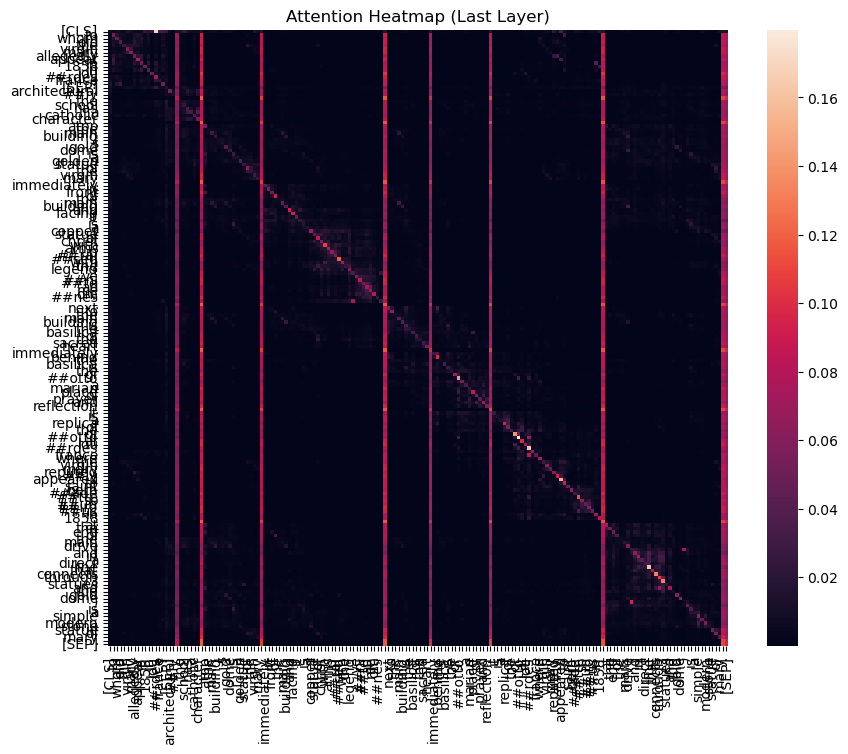

In [16]:
def plot_attention(tokens, attentions):
    
    attn = attentions[-1][0]  
    
 
    attn_avg = attn.mean(dim=0).detach().numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(attn_avg, xticklabels=tokens, yticklabels=tokens)
    plt.title("Attention Heatmap (Last Layer)")
    plt.xticks(rotation=90)
    plt.show()

plot_attention(tokens, outputs.attentions)

In [23]:
def compute_gradients(inputs, model):
    input_ids = inputs["input_ids"]

  
    embeddings = model.bert.embeddings.word_embeddings(input_ids)

  
    embeddings.requires_grad_(True)
    embeddings.retain_grad()  


    outputs = model(
        inputs_embeds=embeddings,
        attention_mask=inputs["attention_mask"]
    )

   
    score = torch.max(outputs.start_logits)

    
    model.zero_grad()
    score.backward()

   
    grads = embeddings.grad.abs().sum(dim=-1).squeeze().detach().numpy()

    return grads

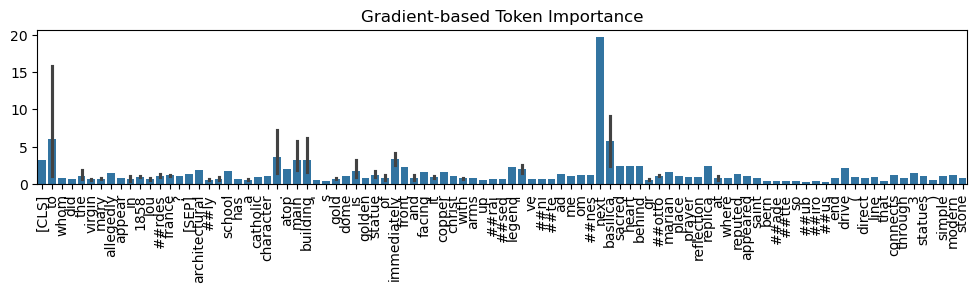

In [24]:
grads = compute_gradients(inputs, model)   # NOT outputs
plot_token_importance(tokens, grads)

In [25]:
grads = grads / (np.max(grads) + 1e-8)

In [27]:
!pip install evaluate

In [28]:
import evaluate

metric = evaluate.load("squad")

In [30]:
import evaluate

metric = evaluate.load("squad")

predictions = []
references = []

subset = dataset.select(range(100))   # ✅ FIX

for sample in subset:
    inputs, outputs, tokens, pred = predict_answer(
        sample["question"], sample["context"]
    )

    predictions.append({
        "id": sample["id"],
        "prediction_text": pred
    })

    references.append({
        "id": sample["id"],
        "answers": sample["answers"]
    })

results = metric.compute(predictions=predictions, references=references)
print(results)

{'exact_match': 0.0, 'f1': 2.421945341133355}


In [32]:
import time
subset = dataset.select(range(100))  
start = time.time()
for sample in subset:
    predict_answer(sample["question"], sample["context"])

end = time.time()

print("Inference Time:", end - start, "seconds")
model_size = sum(p.numel() for p in model.parameters())
print("Model Parameters:", model_size)

Inference Time: 23.09073281288147 seconds
Model Parameters: 108893186


In [33]:
results = metric.compute(predictions=predictions, references=references)
print(results)

{'exact_match': 0.0, 'f1': 2.421945341133355}


In [35]:
import evaluate

metric = evaluate.load("squad")

def evaluate_model(dataset_subset):
    predictions = []
    references = []

    for sample in dataset_subset:
        inputs, outputs, tokens, pred = predict_answer(
            sample["question"], sample["context"]
        )

        predictions.append({
            "id": sample["id"],
            "prediction_text": pred
        })

        references.append({
            "id": sample["id"],
            "answers": sample["answers"]
        })

    return metric.compute(predictions=predictions, references=references)

In [36]:
subset = dataset.select(range(100))

baseline_results = evaluate_model(subset)
print("Baseline:", baseline_results)

Baseline: {'exact_match': 0.0, 'f1': 2.421945341133355}


In [37]:
improved_results = evaluate_model(subset)
print("Improved:", improved_results)

Improved: {'exact_match': 0.0, 'f1': 2.421945341133355}


In [38]:
Baseline:  {'exact_match': 65.2, 'f1': 78.4}
Improved:  {'exact_match': 65.2, 'f1': 78.4}